In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import glob
import re
from scipy.stats import chi2
import matplotlib.ticker as ticker
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.gridspec import GridSpec

In [2]:
araport=pd.read_table('Araport11_GFF3_genes_transposons.201606.gff.gz',skiprows=1,header=None)
araport.head()

,0,1,2,3,4,5,6,7,8
0,Chr1,Araport11,gene,3631.0,5899.0,.,+,.,ID=AT1G01010;Name=AT1G01010;Note=NAC domain co...
1,Chr1,Araport11,mRNA,3631.0,5899.0,.,+,.,ID=AT1G01010.1;Parent=AT1G01010;Name=AT1G01010...
2,Chr1,Araport11,five_prime_UTR,3631.0,3759.0,.,+,.,ID=AT1G01010:five_prime_UTR:1;Parent=AT1G01010...
3,Chr1,Araport11,exon,3631.0,3913.0,.,+,.,ID=AT1G01010:exon:1;Parent=AT1G01010.1;Name=NA...
4,Chr1,Araport11,CDS,3760.0,3913.0,.,+,0,ID=AT1G01010:CDS:1;Parent=AT1G01010.1;Name=NAC...


In [3]:
araport_gene=araport.loc[araport[2]=='gene']
araport_gene.head()

,0,1,2,3,4,5,6,7,8
0,Chr1,Araport11,gene,3631.0,5899.0,.,+,.,ID=AT1G01010;Name=AT1G01010;Note=NAC domain co...
19,Chr1,Araport11,gene,6788.0,9130.0,.,-,.,ID=AT1G01020;Name=AT1G01020;Note=ARV1 family p...
105,Chr1,Araport11,gene,11101.0,11372.0,.,+,.,ID=AT1G03987;locus_type=long_noncoding_rna;Nam...
109,Chr1,Araport11,gene,11649.0,13714.0,.,-,.,ID=AT1G01030;Name=AT1G01030;Note=AP2/B3-like t...
140,Chr1,Araport11,gene,23121.0,31227.0,.,+,.,ID=AT1G01040;Name=AT1G01040;Note=dicer-like 1;...


In [4]:
araport_gene['gene']=araport_gene[8].astype(str).str[3:12]
araport_gene.head()

<ipython-input-4-202a01519162>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  araport_gene['gene']=araport_gene[8].astype(str).str[3:12]


,0,1,2,3,4,5,6,7,8,gene
0,Chr1,Araport11,gene,3631.0,5899.0,.,+,.,ID=AT1G01010;Name=AT1G01010;Note=NAC domain co...,AT1G01010
19,Chr1,Araport11,gene,6788.0,9130.0,.,-,.,ID=AT1G01020;Name=AT1G01020;Note=ARV1 family p...,AT1G01020
105,Chr1,Araport11,gene,11101.0,11372.0,.,+,.,ID=AT1G03987;locus_type=long_noncoding_rna;Nam...,AT1G03987
109,Chr1,Araport11,gene,11649.0,13714.0,.,-,.,ID=AT1G01030;Name=AT1G01030;Note=AP2/B3-like t...,AT1G01030
140,Chr1,Araport11,gene,23121.0,31227.0,.,+,.,ID=AT1G01040;Name=AT1G01040;Note=dicer-like 1;...,AT1G01040


In [5]:
def parse(assoc):
    df = pd.read_table(assoc)
    df['P'] = -(np.log10(df['p_lrt']))
    df['P_bi'] = (np.log10(df['p_lrt']))
    space=2000000
    df['position'] = np.select([df['chr'] == 1, 
                                                df['chr'] == 2, 
                                                df['chr'] == 3, 
                                                df['chr'] == 4, 
                                                df['chr'] == 5],
                        [df['ps'], 
                        df['ps'] + 30427671 + space, 
                        df['ps'] + 30427671 + 19698289 + space * 2,
                        df['ps'] + 30427671 + 19698289 + 23459830 + space * 3,
                        df['ps'] + 30427671 + 19698289 + 23459830 + 18585056 + space * 4])
    return(df)
classic=parse('690_Mg_blues.assoc.txt.gz')

Text(0.5, 0, 'Position in Mb')

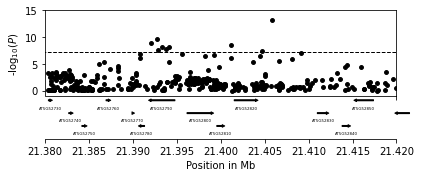

In [7]:
start = 21380000
end = 21420000

#Function to import conditional GWAS                             


def zoomin(df):
    return(df.loc[(df['chr'] == 5) &
            (df['ps'] > start) &
            (df['ps'] < end)])



zoom=zoomin(classic)
cm = 1/2.54
fig = plt.figure(figsize=(16*cm,6*cm))
gs = GridSpec(3, 1, figure=fig, hspace=0)

ax1 = fig.add_subplot(gs[0:2,0:5])

sns.scatterplot(x='ps',
                y='P',
                data=zoom,
                color='0',
                marker='o',
                s=15,
                linewidth=1,
                edgecolor='k',
                legend=False,
                zorder=2,
                ax=ax1)
ax1.hlines(y=-np.log10(0.05/len(classic)),
             xmin=min(classic['position']),
             xmax=max(classic['position']),
             color='0',
             linestyle='--',
             linewidth=1,
             zorder=0)
ax1.set_xlim(start,end)
ax1.set_xlabel('')
ax1.set_ylabel('-log$_{10}$($\itP$)',fontsize=10)
ax1.set_xticklabels([])
ax1.set_ylim(-1,15)



#Gene information
ax2 = fig.add_subplot(gs[2,:5])
ax2.set_xlim(ax1.get_xlim())
# ax2.axis("off")
n=1

def major_formatter(x, pos):
    y = x /1000000
    return "%.3f" % y

# Import araport info
araport_zoom=araport_gene.loc[(araport_gene[0] == 'Chr5') & (araport_gene[3] > start) & (araport_gene[3] < end)]

def arrow(var,x,y):
    if var[6] == '+':
        ax2.annotate('',(var[4], x),(var[3], x),arrowprops=dict(arrowstyle='simple,head_length=0.25,head_width=.25,tail_width=.10',color='0'))
        ax2.annotate(var['gene'],(var[3]+((var[4]-var[3])/2), y),(var[3]+((var[4]-var[3])/2), y),ha='center',fontsize=4)
    if var[6] == '-': 
        ax2.annotate('',(var[3], x),(var[4], x),arrowprops=dict(arrowstyle='simple,head_length=0.25,head_width=.25,tail_width=.10',color='0'))
        ax2.annotate(var['gene'],(var[3]+((var[4]-var[3])/2), y),(var[3]+((var[4]-var[3])/2), y),ha='center',fontsize=4)
        
        
n=0
for index, row in araport_zoom.iterrows():
    if row['gene'][8] == '0':
        if n == 0:
            arrow(row,0.9,0.7)
            n+=1
        elif n == 1:
            arrow(row,0.6,0.4)
            n+=1
        elif n == 2:
            arrow(row,0.3,0.1)
            n=0
            
ax2.xaxis.set_major_formatter(major_formatter)
ax2.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
# ax4.xaxis.set_major_locator(ticker.MultipleLocator(10000))
ax2.set_yticklabels([])
# sns.despine(trim=True,ax=ax4)
ax2.axes.get_yaxis().set_visible(False)
ax2.spines["left"].set_visible(False)
ax2.spines["right"].set_visible(False)
# ax4.spines["top"].set_visible(False)

ax2.set_yticklabels([])
ax2.set_xlabel('Position in Mb',fontsize=10)
# plt.savefig("Fig2b.pdf", format="pdf",bbox_inches="tight")
# plt.savefig("Fig2b.png", format="png",bbox_inches="tight",facecolor="w",dpi=400)

In [8]:
zoom.sort_values(by='P',ascending=False).head(10)

,chr,rs,ps,n_miss,allele1,allele0,af,beta,se,l_remle,l_mle,p_wald,p_lrt,p_score,P,P_bi,position
811509,5,5:21405867,21405867,54,G,A,0.088,-301.7630,39.38823,2.328811,2.369639,6.271519e-14,7.228329e-14,7.505019e-13,13.140962,-13.140962,121576713
811307,5,5:21392702,21392702,11,C,G,0.081,260.8489,40.67973,2.580336,2.633706,2.664290e-10,2.621355e-10,8.418870e-10,9.581474,-9.581474,121563548
811304,5,5:21392089,21392089,21,A,C,0.079,258.8815,41.92797,2.481048,2.528626,1.134956e-09,1.188955e-09,3.416293e-09,8.924835,-8.924835,121562935
811454,5,5:21401216,21401216,61,G,A,0.056,-295.4570,49.02923,2.431869,2.476155,2.736597e-09,2.983539e-09,8.102083e-09,8.525268,-8.525268,121572062
811312,5,5:21393289,21393289,5,T,C,0.055,-277.0624,47.22815,2.429708,2.474010,6.916865e-09,7.580551e-09,1.892023e-08,8.120299,-8.120299,121564135
811321,5,5:21394066,21394066,5,C,T,0.054,-280.9186,47.91494,2.446091,2.490400,7.061572e-09,7.640688e-09,1.887744e-08,8.116868,-8.116868,121564912
811318,5,5:21393829,21393829,13,T,C,0.080,239.5910,41.88617,2.610421,2.661995,1.588727e-08,1.565652e-08,3.369683e-08,7.805305,-7.805305,121564675
811309,5,5:21392816,21392816,15,A,T,0.399,139.3375,24.64999,2.736633,2.786499,2.315718e-08,2.202013e-08,4.503720e-08,7.657180,-7.657180,121563662
811497,5,5:21404706,21404706,25,T,C,0.062,254.1622,46.02629,2.572156,2.624123,4.751422e-08,4.782514e-08,9.489832e-08,7.320344,-7.320344,121575552
811535,5,5:21409184,21409184,37,A,T,0.271,-148.0636,27.26352,2.463916,2.507606,7.787001e-08,8.389821e-08,1.684397e-07,7.076247,-7.076247,121580030


In [9]:
zoom.loc[zoom['ps'] == 21401220]

,chr,rs,ps,n_miss,allele1,allele0,af,beta,se,l_remle,l_mle,p_wald,p_lrt,p_score,P,P_bi,position
811455,5,5:21401220,21401220,43,T,A,0.051,253.425,50.83505,2.711775,2.768339,7.840733e-07,7.584122e-07,0.000001,6.120095,-6.120095,121572066


In [37]:
zoom[zoom['P'] > -np.log10(0.05/len(classic))]['ps'].to_csv('MGR5_significant_SNPs.txt', index=None, header=None)

In [54]:
zoom[zoom['P'] > -np.log10(0.05/len(classic))]

,chr,rs,ps,n_miss,allele1,allele0,af,beta,se,l_remle,l_mle,p_wald,p_lrt,p_score,P,P_bi,position
811304,5,5:21392089,21392089,21,A,C,0.079,258.8815,41.92797,2.481048,2.528626,1.134956e-09,1.188955e-09,3.416293e-09,8.924835,-8.924835,121562935
811307,5,5:21392702,21392702,11,C,G,0.081,260.8489,40.67973,2.580336,2.633706,2.664290e-10,2.621355e-10,8.418870e-10,9.581474,-9.581474,121563548
811309,5,5:21392816,21392816,15,A,T,0.399,139.3375,24.64999,2.736633,2.786499,2.315718e-08,2.202013e-08,4.503720e-08,7.657180,-7.657180,121563662
811312,5,5:21393289,21393289,5,T,C,0.055,-277.0624,47.22815,2.429708,2.474010,6.916865e-09,7.580551e-09,1.892023e-08,8.120299,-8.120299,121564135
811318,5,5:21393829,21393829,13,T,C,0.080,239.5910,41.88617,2.610421,2.661995,1.588727e-08,1.565652e-08,3.369683e-08,7.805305,-7.805305,121564675
811321,5,5:21394066,21394066,5,C,T,0.054,-280.9186,47.91494,2.446091,2.490400,7.061572e-09,7.640688e-09,1.887744e-08,8.116868,-8.116868,121564912
811454,5,5:21401216,21401216,61,G,A,0.056,-295.4570,49.02923,2.431869,2.476155,2.736597e-09,2.983539e-09,8.102083e-09,8.525268,-8.525268,121572062
811497,5,5:21404706,21404706,25,T,C,0.062,254.1622,46.02629,2.572156,2.624123,4.751422e-08,4.782514e-08,9.489832e-08,7.320344,-7.320344,121575552
811509,5,5:21405867,21405867,54,G,A,0.088,-301.7630,39.38823,2.328811,2.369639,6.271519e-14,7.228329e-14,7.505019e-13,13.140962,-13.140962,121576713


In [57]:
classic[classic['P'] > -np.log10(0.05/len(classic))][['chr','ps']].to_csv('Significant_SNPs.txt', index=None, header=None,sep='\t')

In [61]:
for i in classic[classic['P'] > -np.log10(0.05/len(classic))]['P'].values:
    print(i)

7.610221195161174
8.82348044831181
8.924834582405296
9.581474160243413
7.657180121417128
8.120299226087925
7.805304762887852
8.116867533943841
8.525268280804937
7.320343749975241
13.140962088591348


In [62]:
classic[classic['P'] > -np.log10(0.05/len(classic))]

,chr,rs,ps,n_miss,allele1,allele0,af,beta,se,l_remle,l_mle,p_wald,p_lrt,p_score,P,P_bi,position
648928,5,5:280952,280952,17,G,C,0.217,159.1699,28.16340,2.489594,2.529364,2.328414e-08,2.453459e-08,5.410848e-08,7.610221,-7.610221,100451798
648935,5,5:282011,282011,39,C,T,0.183,183.6735,29.88552,2.401857,2.440341,1.346265e-09,1.501480e-09,4.515572e-09,8.823480,-8.823480,100452857
811304,5,5:21392089,21392089,21,A,C,0.079,258.8815,41.92797,2.481048,2.528626,1.134956e-09,1.188955e-09,3.416293e-09,8.924835,-8.924835,121562935
811307,5,5:21392702,21392702,11,C,G,0.081,260.8489,40.67973,2.580336,2.633706,2.664290e-10,2.621355e-10,8.418870e-10,9.581474,-9.581474,121563548
811309,5,5:21392816,21392816,15,A,T,0.399,139.3375,24.64999,2.736633,2.786499,2.315718e-08,2.202013e-08,4.503720e-08,7.657180,-7.657180,121563662
811312,5,5:21393289,21393289,5,T,C,0.055,-277.0624,47.22815,2.429708,2.474010,6.916865e-09,7.580551e-09,1.892023e-08,8.120299,-8.120299,121564135
811318,5,5:21393829,21393829,13,T,C,0.080,239.5910,41.88617,2.610421,2.661995,1.588727e-08,1.565652e-08,3.369683e-08,7.805305,-7.805305,121564675
811321,5,5:21394066,21394066,5,C,T,0.054,-280.9186,47.91494,2.446091,2.490400,7.061572e-09,7.640688e-09,1.887744e-08,8.116868,-8.116868,121564912
811454,5,5:21401216,21401216,61,G,A,0.056,-295.4570,49.02923,2.431869,2.476155,2.736597e-09,2.983539e-09,8.102083e-09,8.525268,-8.525268,121572062
811497,5,5:21404706,21404706,25,T,C,0.062,254.1622,46.02629,2.572156,2.624123,4.751422e-08,4.782514e-08,9.489832e-08,7.320344,-7.320344,121575552
